# 梯度下降

## 演示一：最简示例（手算验证梯度下降）

In [1]:
import torch

# 目标: 学习 y = 2x 这条直线
# 我们用最简单的模型: y = w * x

x = torch.tensor([3.0])   # 输入
true_y = torch.tensor([6.0])  # 真实输出

# 初始猜测 w = 1（随机初始化）
w = torch.tensor([1.0], requires_grad=True)

print("=" * 50)
print("梯度下降演示: 学习 y = 2x")
print(f"输入 x = {x.item()}, 正确输出 y = {true_y.item()}")
print("=" * 50)

learning_rate = 0.1

for step in range(10):
    # 前向传播: 预测
    pred = w * x
    
    # 计算损失 (均方误差)
    loss = (pred - true_y) ** 2
    
    # 反向传播: 自动计算梯度
    loss.backward()
    
    # 打印当前状态
    print(f"Step {step}: w = {w.item():.4f}, "
          f"预测 = {pred.item():.2f}, "
          f"损失 = {loss.item():.4f}, "
          f"梯度 = {w.grad.item():.4f}")
    
    # 梯度下降: 沿梯度反方向更新
    with torch.no_grad():
        w -= learning_rate * w.grad
    
    # 清零梯度（重要！）
    w.grad.zero_()

print(f"\n✅ 学习结果: w = {w.item():.4f} (期望值 2.0)")

梯度下降演示: 学习 y = 2x
输入 x = 3.0, 正确输出 y = 6.0
Step 0: w = 1.0000, 预测 = 3.00, 损失 = 9.0000, 梯度 = -18.0000
Step 1: w = 2.8000, 预测 = 8.40, 损失 = 5.7600, 梯度 = 14.4000
Step 2: w = 1.3600, 预测 = 4.08, 损失 = 3.6864, 梯度 = -11.5200
Step 3: w = 2.5120, 预测 = 7.54, 损失 = 2.3593, 梯度 = 9.2160
Step 4: w = 1.5904, 预测 = 4.77, 损失 = 1.5099, 梯度 = -7.3728
Step 5: w = 2.3277, 预测 = 6.98, 损失 = 0.9664, 梯度 = 5.8982
Step 6: w = 1.7379, 预测 = 5.21, 损失 = 0.6185, 梯度 = -4.7186
Step 7: w = 2.2097, 预测 = 6.63, 损失 = 0.3958, 梯度 = 3.7749
Step 8: w = 1.8322, 预测 = 5.50, 损失 = 0.2533, 梯度 = -3.0199
Step 9: w = 2.1342, 预测 = 6.40, 损失 = 0.1621, 梯度 = 2.4159

✅ 学习结果: w = 1.8926 (期望值 2.0)


## 演示二：可视化梯度下降的“下山”过程

可视化梯度下降: 沿着损失函数曲线下山
初始 w = -1.0
Step 0: w = -1.0000, 损失 = 18.0000, 梯度 = -8.0000
Step 1: w = 1.4000, 损失 = 4.5600, 梯度 = -3.2000
Step 2: w = 2.3600, 损失 = 2.4096, 梯度 = -1.2800
Step 3: w = 2.7440, 损失 = 2.0655, 梯度 = -0.5120
Step 4: w = 2.8976, 损失 = 2.0105, 梯度 = -0.2048
Step 5: w = 2.9590, 损失 = 2.0017, 梯度 = -0.0819
Step 6: w = 2.9836, 损失 = 2.0003, 梯度 = -0.0328
Step 7: w = 2.9934, 损失 = 2.0000, 梯度 = -0.0131
Step 8: w = 2.9974, 损失 = 2.0000, 梯度 = -0.0052
Step 9: w = 2.9990, 损失 = 2.0000, 梯度 = -0.0021
Step 10: w = 2.9996, 损失 = 2.0000, 梯度 = -0.0008
Step 11: w = 2.9998, 损失 = 2.0000, 梯度 = -0.0003
Step 12: w = 2.9999, 损失 = 2.0000, 梯度 = -0.0001
Step 13: w = 3.0000, 损失 = 2.0000, 梯度 = -0.0001
Step 14: w = 3.0000, 损失 = 2.0000, 梯度 = -0.0000


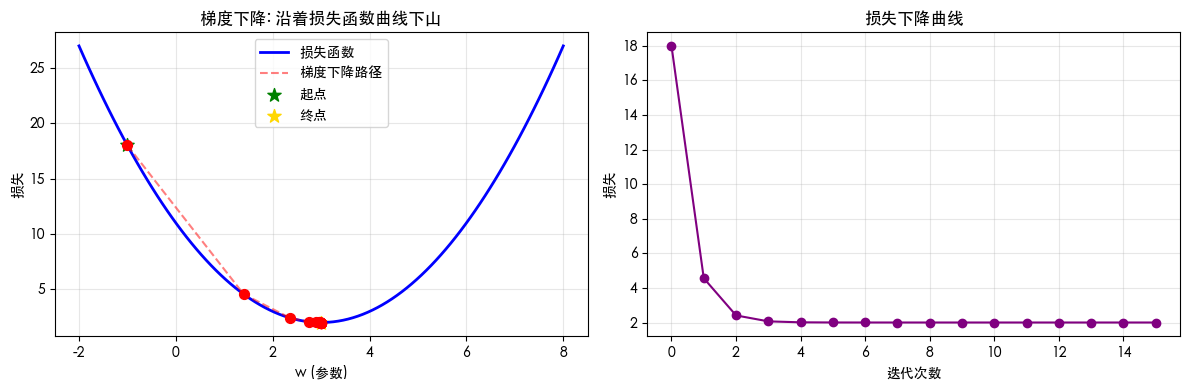


🎯 最终 w = 3.0000 (最优值 = 3.0)
📉 最终损失 = 2.0000 (最小值 = 2.0)


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体（Mac）
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 创建一个更复杂的函数: y = (w - 3)^2 + 2
# 这是一个抛物线，最小值在 w = 3 处，最小值 = 2

def loss_function(w):
    return (w - 3) ** 2 + 2

# 可视化损失函数曲线
w_range = np.linspace(-2, 8, 100)
loss_range = loss_function(w_range)

# 初始化参数（从远离最优点的位置开始）
w = torch.tensor([-1.0], requires_grad=True)

# 记录梯度下降路径
path_w = [w.item()]
path_loss = [loss_function(w.item())]

learning_rate = 0.3

print("=" * 50)
print("可视化梯度下降: 沿着损失函数曲线下山")
print(f"初始 w = {w.item()}")
print("=" * 50)

for step in range(15):
    loss = (w - 3) ** 2 + 2
    loss.backward()
    
    print(f"Step {step}: w = {w.item():.4f}, "
          f"损失 = {loss.item():.4f}, "
          f"梯度 = {w.grad.item():.4f}")
    
    with torch.no_grad():
        w -= learning_rate * w.grad
    
    w.grad.zero_()
    
    path_w.append(w.item())
    path_loss.append(loss_function(w.item()))

# 绘制梯度下降路径
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 左图: 损失函数曲线 + 下降路径
ax1.plot(w_range, loss_range, 'b-', linewidth=2, label='损失函数')
ax1.scatter(path_w, path_loss, c='red', s=50, zorder=5)
ax1.plot(path_w, path_loss, 'r--', alpha=0.5, label='梯度下降路径')
ax1.scatter(path_w[0], path_loss[0], c='green', s=100, marker='*', label='起点')
ax1.scatter(path_w[-1], path_loss[-1], c='gold', s=100, marker='*', label='终点')
ax1.set_xlabel('w (参数)')
ax1.set_ylabel('损失')
ax1.set_title('梯度下降: 沿着损失函数曲线下山')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右图: 损失随迭代次数下降
ax2.plot(range(len(path_loss)), path_loss, 'o-', color='purple')
ax2.set_xlabel('迭代次数')
ax2.set_ylabel('损失')
ax2.set_title('损失下降曲线')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🎯 最终 w = {path_w[-1]:.4f} (最优值 = 3.0)")
print(f"📉 最终损失 = {path_loss[-1]:.4f} (最小值 = 2.0)")

## 演示三：用 3D 展示两个参数的梯度下降

3D 梯度下降演示
初始位置: w1=-1.0, w2=-1.0
----------------------------------------
Step 0: w1=-1.000, w2=-1.000, 损失=25.000
Step 1: w1=0.200, w2=0.600, 损失=9.000
Step 2: w1=0.920, w2=1.560, 损失=3.240
Step 3: w1=1.352, w2=2.136, 损失=1.166
Step 4: w1=1.611, w2=2.482, 损失=0.420
Step 5: w1=1.767, w2=2.689, 损失=0.151
Step 6: w1=1.860, w2=2.813, 损失=0.054
Step 7: w1=1.916, w2=2.888, 损失=0.020
Step 8: w1=1.950, w2=2.933, 损失=0.007
Step 9: w1=1.970, w2=2.960, 损失=0.003
Step 10: w1=1.982, w2=2.976, 损失=0.001
Step 11: w1=1.989, w2=2.985, 损失=0.000
Step 12: w1=1.993, w2=2.991, 损失=0.000
Step 13: w1=1.996, w2=2.995, 损失=0.000
Step 14: w1=1.998, w2=2.997, 损失=0.000
Step 15: w1=1.999, w2=2.998, 损失=0.000
Step 16: w1=1.999, w2=2.999, 损失=0.000
Step 17: w1=1.999, w2=2.999, 损失=0.000
Step 18: w1=2.000, w2=3.000, 损失=0.000
Step 19: w1=2.000, w2=3.000, 损失=0.000


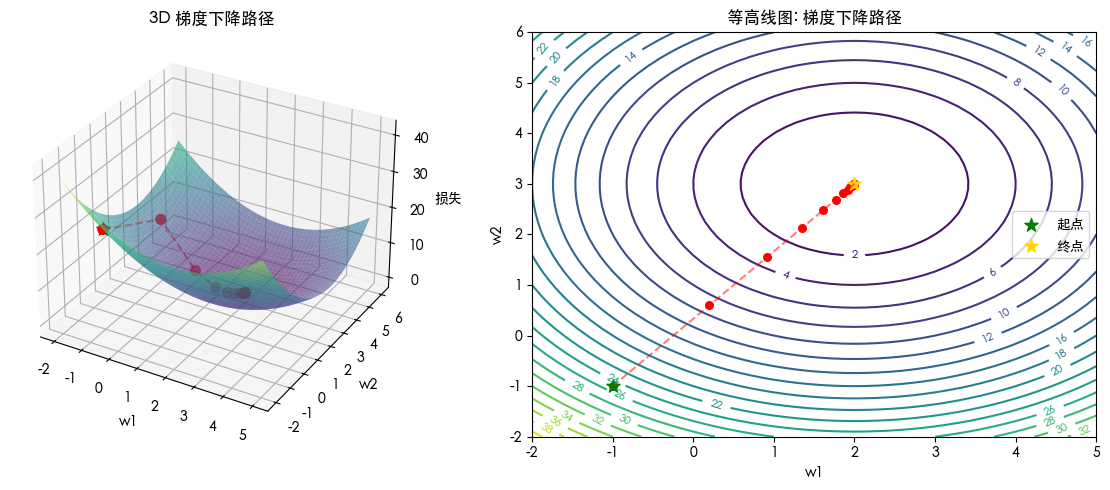

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 创建一个简单的二维损失函数: loss = (w1 - 2)^2 + (w2 - 3)^2
# 这是一个抛物面，最小值在 (2, 3)

def loss_function_2d(w1, w2):
    return (w1 - 2) ** 2 + (w2 - 3) ** 2

# 初始化参数
w1 = torch.tensor([-1.0], requires_grad=True)
w2 = torch.tensor([-1.0], requires_grad=True)

# 记录路径
path_w1 = [w1.item()]
path_w2 = [w2.item()]
path_loss = [loss_function_2d(w1.item(), w2.item())]

learning_rate = 0.2

print("3D 梯度下降演示")
print(f"初始位置: w1={w1.item()}, w2={w2.item()}")
print("-" * 40)

for step in range(20):
    loss = (w1 - 2) ** 2 + (w2 - 3) ** 2
    loss.backward()
    
    print(f"Step {step}: "
          f"w1={w1.item():.3f}, "
          f"w2={w2.item():.3f}, "
          f"损失={loss.item():.3f}")
    
    with torch.no_grad():
        w1 -= learning_rate * w1.grad
        w2 -= learning_rate * w2.grad
    
    w1.grad.zero_()
    w2.grad.zero_()
    
    path_w1.append(w1.item())
    path_w2.append(w2.item())
    path_loss.append(loss.item())

# 绘制 3D 图
fig = plt.figure(figsize=(12, 5))

# 3D 曲面图
ax1 = fig.add_subplot(121, projection='3d')
w1_grid = np.linspace(-2, 5, 50)
w2_grid = np.linspace(-2, 6, 50)
W1, W2 = np.meshgrid(w1_grid, w2_grid)
Z = loss_function_2d(W1, W2)

ax1.plot_surface(W1, W2, Z, cmap='viridis', alpha=0.6, edgecolor='none')
ax1.scatter(path_w1, path_w2, path_loss, c='red', s=50)
ax1.plot(path_w1, path_w2, path_loss, 'r--', alpha=0.5)
ax1.scatter(path_w1[0], path_w2[0], path_loss[0], c='green', s=100, marker='*', label='起点')
ax1.scatter(path_w1[-1], path_w2[-1], path_loss[-1], c='gold', s=100, marker='*', label='终点')
ax1.set_xlabel('w1')
ax1.set_ylabel('w2')
ax1.set_zlabel('损失')
ax1.set_title('3D 梯度下降路径')

# 等高线图
ax2 = fig.add_subplot(122)
contour = ax2.contour(W1, W2, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.scatter(path_w1, path_w2, c='red', s=30)
ax2.plot(path_w1, path_w2, 'r--', alpha=0.5)
ax2.scatter(path_w1[0], path_w2[0], c='green', s=100, marker='*', label='起点')
ax2.scatter(path_w1[-1], path_w2[-1], c='gold', s=100, marker='*', label='终点')
ax2.set_xlabel('w1')
ax2.set_ylabel('w2')
ax2.set_title('等高线图: 梯度下降路径')
ax2.legend()

plt.tight_layout()
plt.show()

## 演示四：动画版

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 准备动画数据
w_range = np.linspace(-2, 8, 100)
loss_range = (w_range - 3) ** 2 + 2

# 梯度下降过程
w = torch.tensor([-1.0], requires_grad=True)
learning_rate = 0.3

history_w = []
history_loss = []

for step in range(15):
    loss = (w - 3) ** 2 + 2
    loss.backward()
    history_w.append(w.item())
    history_loss.append(loss.item())
    with torch.no_grad():
        w -= learning_rate * w.grad
    w.grad.zero_()

# 创建动画
fig, ax = plt.subplots(figsize=(10, 6))

def update(frame):
    ax.clear()
    ax.plot(w_range, loss_range, 'b-', linewidth=2, label='损失函数')
    ax.scatter(history_w[:frame+1], history_loss[:frame+1], 
               c='red', s=80, zorder=5)
    ax.plot(history_w[:frame+1], history_loss[:frame+1], 
            'r--', alpha=0.5)
    ax.scatter(history_w[frame], history_loss[frame], 
               c='red', s=150, marker='o', edgecolor='darkred')
    ax.scatter(history_w[0], history_loss[0], 
               c='green', s=150, marker='*', label='起点')
    ax.scatter(history_w[-1], history_loss[-1], 
               c='gold', s=150, marker='*', label='终点')
    ax.set_xlabel('w (参数)')
    ax.set_ylabel('损失')
    ax.set_title(f'梯度下降动画 (第 {frame+1} 步)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2, 8)
    ax.set_ylim(0, 30)

# 生成动画
anim = FuncAnimation(fig, update, frames=len(history_w), 
                     interval=500, repeat=True)

plt.close()
HTML(anim.to_jshtml())

## 演示五：复杂函数（多谷底）的梯度下降

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("演示五：复杂函数（多谷底）的梯度下降")
print("=" * 60)

# 定义一个复杂的一维函数：多个波峰波谷
# f(x) = sin(x) + 0.3 * sin(3x) + 0.2 * sin(5x) + 0.1 * x^2（轻微倾斜）
def complex_loss_1d(x):
    return torch.sin(x) + 0.3 * torch.sin(3 * x) + 0.2 * torch.sin(5 * x) + 0.05 * x ** 2

# 定义其 numpy 版本用于绘图
def complex_loss_np(x):
    return np.sin(x) + 0.3 * np.sin(3 * x) + 0.2 * np.sin(5 * x) + 0.05 * x ** 2

# 生成 x 范围
x_range = np.linspace(-4, 6, 500)
loss_range = complex_loss_np(x_range)

# 找到全局最小值的大概位置（用于对比）
global_min_idx = np.argmin(loss_range)
global_min_x = x_range[global_min_idx]
global_min_y = loss_range[global_min_idx]

print(f"📊 函数特征：多个局部极小值，全局最小值大约在 x = {global_min_x:.2f}")
print("-" * 60)

演示五：复杂函数（多谷底）的梯度下降
📊 函数特征：多个局部极小值，全局最小值大约在 x = -0.51
------------------------------------------------------------



🎯 实验1：从不同起点出发的梯度下降
  起点 -3.0 → 终点 -2.568 (损失: -0.5636)
  起点 -1.2 → 终点 -1.524 (损失: -0.7803)
  起点  0.5 → 终点 -0.515 (损失: -0.8865)
  起点  2.5 → 终点  2.063 (损失: 0.9104)
  起点  4.0 → 终点  3.607 (损失: -0.2392)


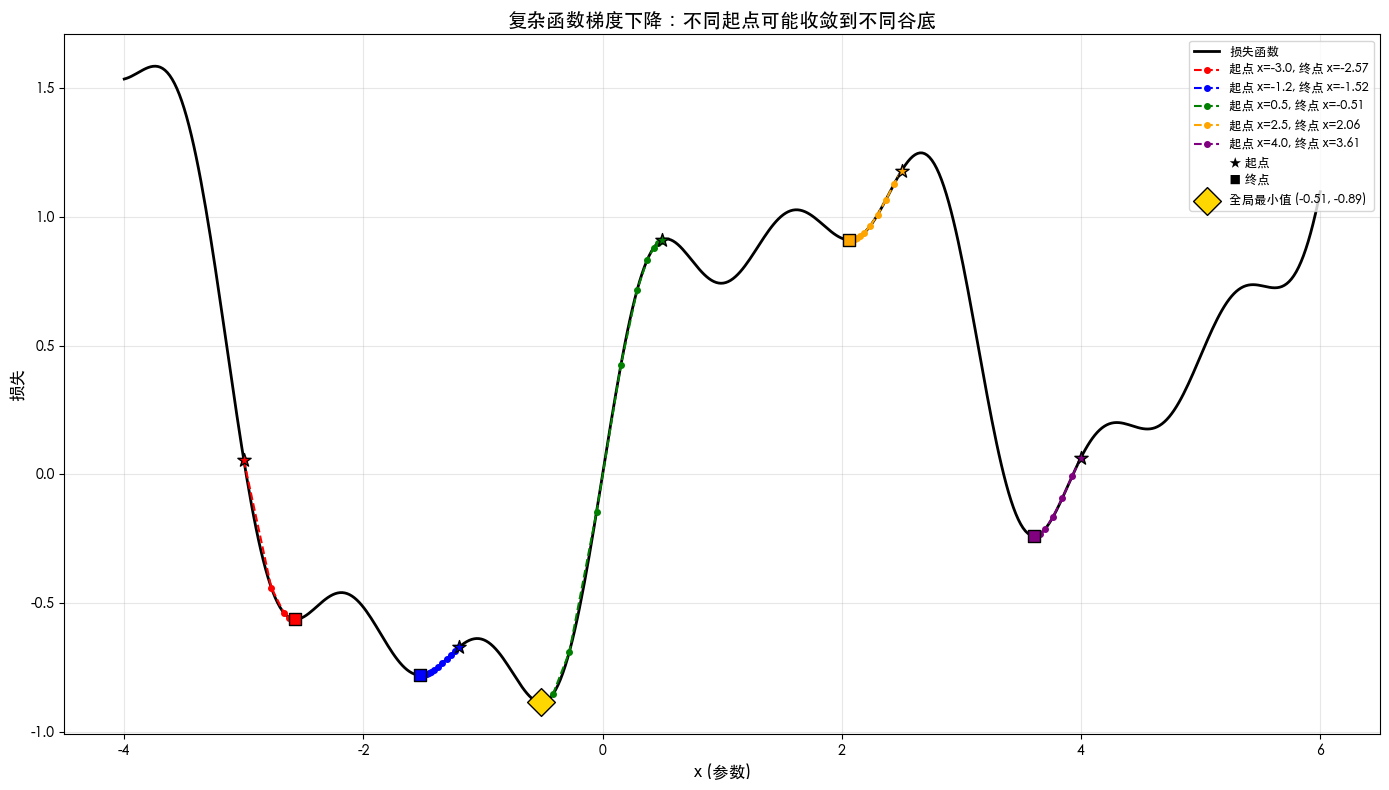


💡 核心观察：梯度下降可能收敛到局部最小值，而非全局最小值！
   起点不同，终点可能完全不同——这就是"局部最优陷阱"。


In [6]:
# ========== 实验1：从不同起点出发 ==========
print("\n🎯 实验1：从不同起点出发的梯度下降")

start_points = [-3.0, -1.2, 0.5, 2.5, 4.0]
colors = ['red', 'blue', 'green', 'orange', 'purple']
learning_rate = 0.08
steps = 40

plt.figure(figsize=(14, 8))
plt.plot(x_range, loss_range, 'k-', linewidth=2, label='损失函数')

for start_x, color in zip(start_points, colors):
    # 初始化参数
    x = torch.tensor([start_x], requires_grad=True)
    path_x = [x.item()]
    path_loss = [complex_loss_1d(x).item()]
    
    for step in range(steps):
        loss = complex_loss_1d(x)
        loss.backward()
        
        with torch.no_grad():
            x -= learning_rate * x.grad
        
        x.grad.zero_()
        path_x.append(x.item())
        path_loss.append(complex_loss_1d(x).item())
    
    # 绘制路径
    plt.plot(path_x, path_loss, 'o--', color=color, linewidth=1.5, 
             markersize=4, label=f'起点 x={start_x}, 终点 x={x.item():.2f}')
    plt.scatter(path_x[0], path_loss[0], color=color, s=100, 
                marker='*', edgecolors='black', zorder=5)
    plt.scatter(path_x[-1], path_loss[-1], color=color, s=80, 
                marker='s', edgecolors='black', zorder=5)
    
    print(f"  起点 {start_x:4.1f} → 终点 {x.item():6.3f} (损失: {complex_loss_1d(x).item():.4f})")

plt.scatter([], [], c='white', marker='*', s=100, label='★ 起点')
plt.scatter([], [], c='white', marker='s', s=80, label='■ 终点')
plt.scatter(global_min_x, global_min_y, c='gold', s=200, marker='D', 
            edgecolors='black', label=f'全局最小值 ({global_min_x:.2f}, {global_min_y:.2f})', zorder=10)

plt.xlabel('x (参数)', fontsize=12)
plt.ylabel('损失', fontsize=12)
plt.title('复杂函数梯度下降：不同起点可能收敛到不同谷底', fontsize=14)
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 核心观察：梯度下降可能收敛到局部最小值，而非全局最小值！")
print("   起点不同，终点可能完全不同——这就是\"局部最优陷阱\"。")


🎯 实验2：二维复杂函数（多个谷底）


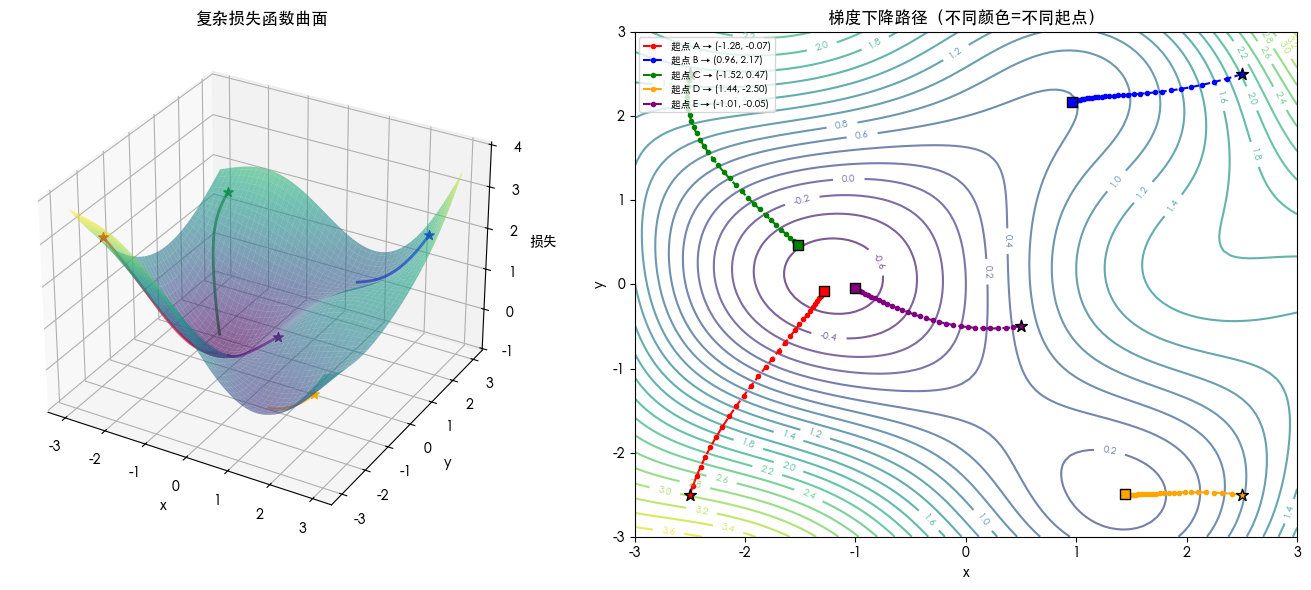


💡 核心观察：
   1. 二维曲面上有多个"盆地"（局部最小值）
   2. 不同起点沿着最陡方向下滑，可能落入不同盆地
   3. 这就是为什么神经网络需要多次随机初始化！


In [7]:
# ========== 实验2：二维复杂函数（多个局部谷底） ==========
print("\n" + "=" * 60)
print("🎯 实验2：二维复杂函数（多个谷底）")

# 定义一个复杂二维函数：有多个局部极小值的曲面
# f(x,y) = sin(x)*cos(y) + 0.2*(x^2 + y^2) + 0.1*x*y
def complex_loss_2d(x, y):
    return (torch.sin(x) * torch.cos(y) + 
            0.15 * (x**2 + y**2) + 
            0.1 * x * y)

def complex_loss_2d_np(x, y):
    return (np.sin(x) * np.cos(y) + 
            0.15 * (x**2 + y**2) + 
            0.1 * x * y)

# 创建网格
x_grid = np.linspace(-3, 3, 100)
y_grid = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = complex_loss_2d_np(X, Y)

# 从多个不同起点进行梯度下降
start_points_2d = [
    (-2.5, -2.5, 'red', '起点 A'),
    (2.5, 2.5, 'blue', '起点 B'),
    (-2.5, 2.5, 'green', '起点 C'),
    (2.5, -2.5, 'orange', '起点 D'),
    (0.5, -0.5, 'purple', '起点 E')
]

fig = plt.figure(figsize=(14, 6))

# 3D 曲面图
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, edgecolor='none')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('损失')
ax1.set_title('复杂损失函数曲面', fontsize=12)

# 等高线图（绘制梯度下降路径）
ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=25, cmap='viridis', alpha=0.7)
ax2.clabel(contour, inline=True, fontsize=7)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('梯度下降路径（不同颜色=不同起点）', fontsize=12)

learning_rate_2d = 0.08
steps_2d = 30

for start_x, start_y, color, label in start_points_2d:
    x = torch.tensor([start_x], requires_grad=True)
    y = torch.tensor([start_y], requires_grad=True)
    
    path_x = [x.item()]
    path_y = [y.item()]
    path_z = [complex_loss_2d(x, y).item()]
    
    for step in range(steps_2d):
        loss = complex_loss_2d(x, y)
        loss.backward()
        
        with torch.no_grad():
            x -= learning_rate_2d * x.grad
            y -= learning_rate_2d * y.grad
        
        x.grad.zero_()
        y.grad.zero_()
        
        path_x.append(x.item())
        path_y.append(y.item())
        path_z.append(complex_loss_2d(x, y).item())
    
    # 在等高线图上绘制路径
    ax2.plot(path_x, path_y, 'o--', color=color, linewidth=1.5, 
             markersize=3, label=f'{label} → ({x.item():.2f}, {y.item():.2f})')
    ax2.scatter(path_x[0], path_y[0], color=color, s=80, marker='*', edgecolors='black', zorder=5)
    ax2.scatter(path_x[-1], path_y[-1], color=color, s=60, marker='s', edgecolors='black', zorder=5)
    
    # 在3D图上绘制路径
    ax1.plot(path_x, path_y, path_z, color=color, linewidth=2, alpha=0.7)
    ax1.scatter(path_x[0], path_y[0], path_z[0], color=color, s=50, marker='*')

ax2.legend(loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

print("\n💡 核心观察：")
print("   1. 二维曲面上有多个\"盆地\"（局部最小值）")
print("   2. 不同起点沿着最陡方向下滑，可能落入不同盆地")
print("   3. 这就是为什么神经网络需要多次随机初始化！")

In [16]:
# ========== 实验3：动画演示（一维多谷底） ==========
print("\n" + "=" * 60)
print("🎯 实验3：动画演示 - 复杂函数梯度下降")

# 重新计算路径（从最差的起点开始）
x_start = 2.6
x = torch.tensor([x_start], requires_grad=True)
learning_rate_anim = 0.5
steps_anim = 50

path_x_anim = [x.item()]
path_loss_anim = [complex_loss_1d(x).item()]

for step in range(steps_anim):
    loss = complex_loss_1d(x)
    loss.backward()
    with torch.no_grad():
        x -= learning_rate_anim * x.grad
    x.grad.zero_()
    path_x_anim.append(x.item())
    path_loss_anim.append(complex_loss_1d(x).item())

fig, ax = plt.subplots(figsize=(12, 6))

def update(frame):
    ax.clear()
    ax.plot(x_range, loss_range, 'k-', linewidth=2, label='损失函数')
    
    # 绘制已走过的路径
    ax.plot(path_x_anim[:frame+1], path_loss_anim[:frame+1], 
            'r--', alpha=0.5, linewidth=1)
    ax.scatter(path_x_anim[:frame+1], path_loss_anim[:frame+1], 
               c='red', s=30, alpha=0.6)
    
    # 标记当前位置
    ax.scatter(path_x_anim[frame], path_loss_anim[frame], 
               c='red', s=150, marker='o', edgecolors='darkred', 
               label='当前位置', zorder=5)
    
    # 标记起点和终点
    ax.scatter(path_x_anim[0], path_loss_anim[0], 
               c='green', s=150, marker='*', label='起点', zorder=5)
    ax.scatter(path_x_anim[-1], path_loss_anim[-1], 
               c='gold', s=150, marker='*', label='终点', zorder=5)
    
    # 标记全局最小值
    ax.scatter(global_min_x, global_min_y, c='purple', s=150, 
               marker='D', label=f'全局最小值', zorder=5)
    
    ax.set_xlabel('x (参数)', fontsize=12)
    ax.set_ylabel('损失', fontsize=12)
    ax.set_title(f'复杂函数梯度下降动画 (第 {frame+1}/{len(path_x_anim)} 步)', fontsize=14)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-4, 6)
    ax.set_ylim(-1.5, 2.5)

anim = FuncAnimation(fig, update, frames=len(path_x_anim), 
                     interval=100, repeat=True)

plt.close()
HTML(anim.to_jshtml())

print("\n✅ 动画已生成，请在 Jupyter 中运行查看")


🎯 实验3：动画演示 - 复杂函数梯度下降

✅ 动画已生成，请在 Jupyter 中运行查看


In [17]:
display(HTML(anim.to_jshtml()))